# Bias Analysis of Credit Approval Decisions – NovaCred

This notebook investigates potential bias in NovaCred’s historical credit decisions. 
The objective is to evaluate whether protected attributes such as **gender** or **age** influence loan approval outcomes.

We begin by preparing the dataset and ensuring that the relevant attributes are standardized. 
In particular, we need to check that all gender labels must be consistent and that the applicant’s birthdate is valid, as we are deriving age from it.

Once the dataset is prepared, we conduct several fairness analyses:

1. **Gender Disparate Impact Analysis** – evaluating whether approval rates differ significantly between male and female applicants using the four-fifths rule.
2. **Age-Based Bias Analysis** – examining approval patterns across different age groups.
3. **Proxy Discrimination Analysis** – investigating whether unprotected variables, such as ZIP code, indirectly capture protected characteristics, such as age and gender.
4. **Interaction Effects** – exploring whether combinations of age and gender produce systematic differences in approval outcomes.

These analyses aim to identify potential algorithmic bias in the lending process and assess whether the system may produce discriminatory outcomes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df_bias = pd.read_json("../data/processed/cleaned_credit_applications.json", orient="records")
print("Dataset shape:", df_bias.shape)


Dataset shape: (500, 34)


----
## 0. Data Preparation and Validation for Bias Analysis

Before performing any fairness analysis, we need to verify that key attributes used in the
analysis are correctly formatted and contain expected values.

The following checks are performed:

- Validate that the gender column contains only expected categories
- Convert valid dates of birth to datetime format in order to derive the applicant's age

These validation steps ensure that the fairness analysis is based on
well-defined and reliable variables.


In [2]:
print("===== BIAS ANALYSIS DATA CHECKS =====\n")

# --- Inspect gender values ---
print("Gender value counts:")
print(df_bias['applicant_info.gender'].value_counts(dropna=False))

print("\nUnique gender values:")
print(df_bias['applicant_info.gender'].unique())

# --- Convert DOB ---
df_bias['applicant_info.date_of_birth'] = pd.to_datetime(
    df_bias['applicant_info.date_of_birth'], errors='coerce'
)

print("\nInvalid DOB values:",
      df_bias['applicant_info.date_of_birth'].isna().sum())


# --- Missing values check ---
cols_to_check = [
    'applicant_info.gender',
    'applicant_info.date_of_birth',
    'decision.loan_approved'
]

print("\nMissing values in key columns:")
print(df_bias[cols_to_check].isnull().sum())


===== BIAS ANALYSIS DATA CHECKS =====

Gender value counts:
applicant_info.gender
Female    251
Male      247
            2
Name: count, dtype: int64

Unique gender values:
['Male' 'Female' '']

Invalid DOB values: 4

Missing values in key columns:
applicant_info.gender           0
applicant_info.date_of_birth    4
decision.loan_approved          0
dtype: int64


The diagnostic checks reveal two minor data issues that must be addressed before conducting fairness analysis.

First, two records contain empty values in the gender field. Since disparate impact analysis requires clearly defined demographic groups, these records cannot be reliably assigned to either group and will therefore be excluded from the gender fairness analysis.

Second, four records contain invalid or missing birthdates, which prevents accurate age calculation. These records will also be excluded from analyses involving age-based bias.

In [3]:
# Remove records with unknown gender
df_bias = df_bias[df_bias['applicant_info.gender'].isin(['Male', 'Female'])]

# Remove rows with invalid DOB
df_bias = df_bias[df_bias['applicant_info.date_of_birth'].notna()]

# Recalculate age
today = pd.Timestamp.today()
df_bias['age'] = (today - df_bias['applicant_info.date_of_birth']).dt.days // 365

print("Final dataset size:", len(df_bias))
print(df_bias['applicant_info.gender'].value_counts())

Final dataset size: 495
applicant_info.gender
Female    249
Male      246
Name: count, dtype: int64


------


## 1. Gender Disparate Impact Analysis

Credit approval systems must be evaluated for potential discrimination against protected groups. 
One commonly used fairness metric is the **Disparate Impact (DI) ratio**, which compares the 
approval rate of an unprivileged group to that of a privileged group.


In [4]:
approval_summary = df_bias.groupby('applicant_info.gender').agg(
    applicants=('decision.loan_approved', 'count'),
    approved=('decision.loan_approved', 'sum')
)

approval_summary['approval_rate'] = approval_summary['approved'] / approval_summary['applicants']

approval_summary

,applicants,approved,approval_rate
applicant_info.gender,,,
Female,249,126,0.506024
Male,246,162,0.658537


In fairness analysis, the group with the historically higher approval rate is often used as the privileged reference group. 
In this dataset, male applicants exhibit the higher approval rate and are therefore treated as the privileged group for the Disparate Impact calculation.


The Disparate Impact (DI) is calculated as:

DI = Approval Rate (Female) / Approval Rate (Male)

According to the four-fifths rule, values below 0.8 may indicate potential discrimination.


Disparate Impact Ratio: 0.7684069611780454


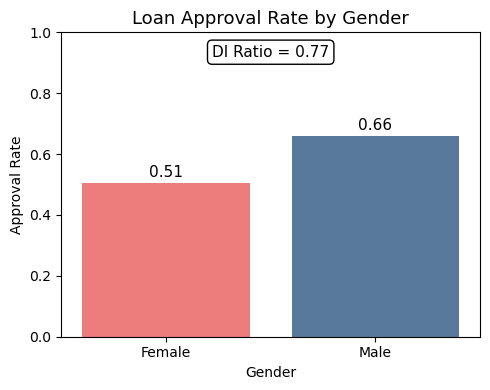

In [21]:
# Extract approval rates from summary table
female_rate = approval_summary.loc['Female', 'approval_rate']
male_rate = approval_summary.loc['Male', 'approval_rate']

# Compute Disparate Impact
di_ratio = female_rate / male_rate

print("\nDisparate Impact Ratio:", di_ratio)


# Plot approval rate by gender
plt.figure(figsize=(5,4))

sns.barplot(
    x=approval_summary.index,
    y=approval_summary['approval_rate'],
    palette=["#FF6B6B", "#4E79A7"]
)

plt.title("Loan Approval Rate by Gender", fontsize=13)
plt.xlabel("Gender")
plt.ylabel("Approval Rate")
plt.ylim(0,1)

# Add approval rate labels above bars
for i, v in enumerate(approval_summary['approval_rate']):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=11)

# Add DI ratio annotation
plt.text(
    0.5, 0.92,
    f"DI Ratio = {di_ratio:.2f}",
    ha='center',
    fontsize=11,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round')
)

plt.tight_layout()
plt.show()

The **Disparate Impact ratio is 0.77**, indicating that female applicants are approved at
only 77% of the rate of male applicants. Because this falls below the 0.8 threshold, this suggests that the approval process may have a 
disproportionately adverse effect on female applicants, raising serious fairness and 
compliance concerns.

To determine whether this observed difference represents a systematic 
pattern or could have occurred by random chance, we perform a Chi-Square test.

In [6]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df_bias['applicant_info.gender'],
    df_bias['decision.loan_approved']
)

chi2_gender, p_value_gender, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2_gender:.2f}")
print(f"p-value: {p_value_gender:.4f}")

Chi-square statistic: 11.21
p-value: 0.0008


With a p-value of 0.0008, which is far below the significance threshold of 0.05, 
we reject the null hypothesis that gender and approval outcomes are independent. 
This provides strong statistical evidence that the gender disparity is not due to chance 
but represents a systematic pattern in the lending decisions.

Combined with the DI ratio of 0.77 (below the 0.8 threshold), this 
constitutes **strong statistical evidence of a gender disparity in approval outcomes in NovaCred's 
credit system**.

----
## 2. Age Bias Analysis

In addition to gender, **age** might also influence lending decisions. Financial
characteristics such as income, savings, and credit history often vary
across age groups, which may lead to differences in approval outcomes.

To investigate potential **age-related disparities**, we examine how loan
approval rates vary across different age groups. 

To do so, we will start by groupping applicants into age ranges to compare approval outcomes
across different stages of the working population.

In [7]:
bins = [18, 25, 35, 50, 65, 100]
labels = ["18–25", "26–35", "36–50", "51–65", "65+"]

df_bias["age_group"] = pd.cut(
    df_bias["age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

age_summary = df_bias.groupby("age_group").agg(
    applicants=("decision.loan_approved", "count"),
    approved=("decision.loan_approved", "sum")
)

age_summary["approval_rate"] = age_summary["approved"] / age_summary["applicants"]

age_summary

,applicants,approved,approval_rate
age_group,,,
18–25,22,10,0.454545
26–35,157,73,0.464968
36–50,225,153,0.680000
51–65,83,48,0.578313
65+,8,4,0.500000


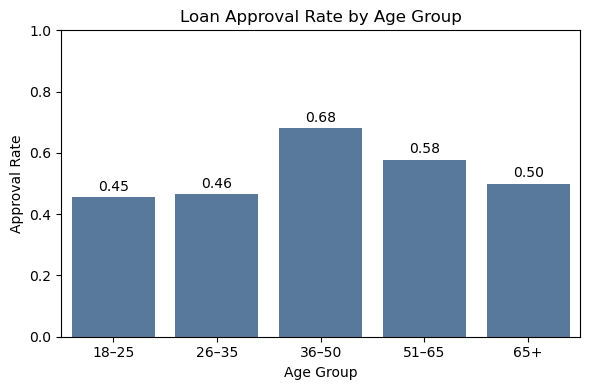

In [8]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=age_summary.index,
    y=age_summary["approval_rate"],
    color="#4E79A7"
)

plt.title("Loan Approval Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Approval Rate")
plt.ylim(0,1)

for i, v in enumerate(age_summary["approval_rate"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

Approval rates vary across age groups. The **18–25** and **26–35** groups have the
lowest approval rates (around **45–46%**), while the **36–50** group has the highest
approval rate at **68%**. Approval rates then decrease slightly for older applicants. This pattern suggests that younger applicants are less likely to receive loan
approvals compared to middle-aged applicants.


To assess whether these observed differences are statistically significant or could 
be due to random variation, we perform a Chi-Square test of independence.

In [9]:
contingency_table_age = pd.crosstab(
    df_bias["age_group"],
    df_bias["decision.loan_approved"]
)

chi2_age, p_value_age, dof_age, expected_age = chi2_contingency(contingency_table_age)

print(f"Chi-square statistic: {chi2_age:.2f}")
print(f"p-value: {p_value_age:.4f}")

Chi-square statistic: 19.41
p-value: 0.0007


With a p-value of **0.0007**, which is **far below the significance threshold of 0.05**, 
we **reject the null hypothesis** that age group and approval outcomes are independent. 
This provides strong statistical evidence that approval rates are not randomly 
distributed across age groups but vary systematically with age.

However, these patterns alone do
not necessarily indicate discriminatory decision-making. Age is often
associated with financial characteristics such as income, credit
history length, and savings accumulation, which are legitimate risk
factors in credit evaluation.

Because these financial variables may be correlated with age, observed
differences in approval outcomes could reflect underlying financial
profiles rather than direct age discrimination.

To better understand whether demographic attributes may influence
approval outcomes indirectly, the next section investigates **proxy
variables**. 

---
## 3. Proxy Discrimination Analysis

Bias in decision systems does not always arise from the direct use of
protected attributes such as gender or age. Instead, **proxy variables**
may indirectly transmit demographic patterns into model decisions.

A proxy variable is a non-protected attribute that is correlated with
protected characteristics and therefore may reproduce demographic
disparities even when sensitive attributes are not explicitly used.

In credit decision systems, potential proxies may include:

- **Geographic variables** (such as ZIP code), which may reflect
  demographic or socioeconomic patterns.
- **Financial attributes** (such as income or credit history length),
  which may correlate with demographic characteristics such as age.

To evaluate whether proxy relationships may exist in this dataset, we
analyze:

1. Whether approval outcomes vary across ZIP codes.
2. Whether ZIP codes are associated with demographic characteristics
   such as gender and age.
3. Whether financial attributes correlate with demographic variables
   and approval outcomes.

Together, these analyses help determine whether **indirect pathways**
exist through which demographic characteristics could influence
credit decisions.

### 3.1 Geographic Proxy Analysis

Geographic attributes such as ZIP codes may function as proxy variables
for demographic or socioeconomic characteristics. If approval rates vary
systematically across locations, geographic information could indirectly
encode demographic patterns even when protected attributes are not used
explicitly in the decision process.

Before analyzing approval rates across ZIP codes, we examine the number
of applications per geographic area. Some ZIP codes may appear only a
few times in the dataset, which can produce unstable approval rates.

In [10]:
zip_counts = df_bias['applicant_info.zip_code'].value_counts()

print("=== ZIP CODE DISTRIBUTION ===\n")
print(f"Total unique ZIP codes: {len(zip_counts)}")
print(f"Applications range: {zip_counts.min()} to {zip_counts.max()}\n")

print("Most frequent ZIP codes (top 5):")
print(zip_counts.head(5))

print("\nLeast frequent ZIP codes (bottom 5):")
print(zip_counts.tail(5))

print(f"\nZIP codes with fewer than 5 applications: {(zip_counts < 5).sum()}")
print(f"ZIP codes with 5+ applications: {(zip_counts >= 5).sum()}")

=== ZIP CODE DISTRIBUTION ===

Total unique ZIP codes: 194
Applications range: 1 to 8

Most frequent ZIP codes (top 5):
applicant_info.zip_code
10048    8
10096    7
90284    7
10004    6
10019    6
Name: count, dtype: int64

Least frequent ZIP codes (bottom 5):
applicant_info.zip_code
30047    1
30012    1
90212    1
10016    1
90220    1
Name: count, dtype: int64

ZIP codes with fewer than 5 applications: 175
ZIP codes with 5+ applications: 19


Because many ZIP codes appear only a few times in the dataset, approval
rates could become artificially extreme (for example 0% or 100%). To ensure
more stable comparisons, the analysis
includes only ZIP codes with at least five applications.

In [11]:
valid_zips = zip_counts[zip_counts >= 5].index

df_zip_filtered = df_bias[
    df_bias['applicant_info.zip_code'].isin(valid_zips)
]

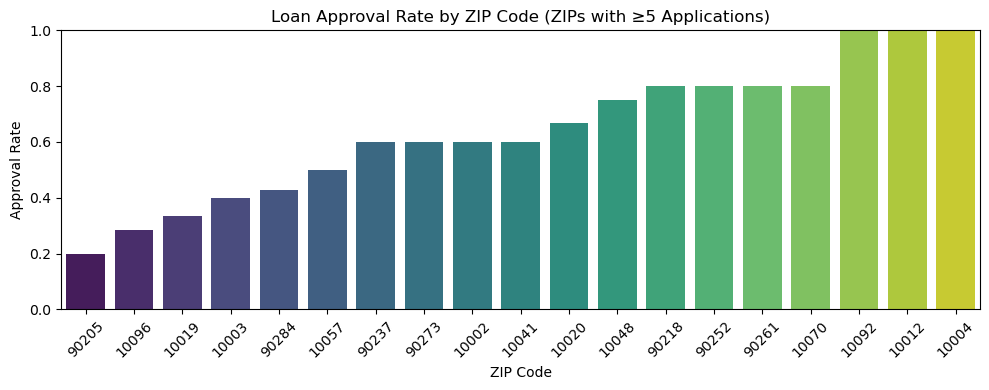

In [12]:
zip_approval = df_zip_filtered.groupby(
    'applicant_info.zip_code'
)['decision.loan_approved'].mean()

zip_approval = zip_approval.sort_values()


plt.figure(figsize=(10,4))

sns.barplot(
    x=zip_approval.index.astype(str),
    y=zip_approval.values,
    palette="viridis"
)

plt.title("Loan Approval Rate by ZIP Code (ZIPs with ≥5 Applications)")
plt.xlabel("ZIP Code")
plt.ylabel("Approval Rate")

plt.ylim(0,1)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The approval rates vary considerably across ZIP codes. Among ZIP codes
with at least five applications, approval rates range from approximately
20% to 100%. This variation suggests that location may be associated
with different lending outcomes.

To assess whether the observed differences are
statistically significant, we perform a chi-square test of independence
between ZIP code and loan approval outcome.

The chi-square test evaluates whether approval decisions are independent
of geographic location. A statistically significant result would indicate
that approval rates differ systematically across ZIP codes.

In [ ]:
zip_approval_table = pd.crosstab(
    df_zip_filtered['applicant_info.zip_code'],
    df_zip_filtered['decision.loan_approved']
)

from scipy.stats import chi2_contingency

chi2_zip, p_value_zip, dof, expected = chi2_contingency(zip_approval_table)

print(f"Chi-square statistic: {chi2_zip:.2f}")
print(f"p-value: {p_value_zip:.4f}")

The chi-square test produced a statistic of **25.12** with a **p-value of 0.1217**.

Because the p-value is greater than the conventional significance threshold
of 0.05, we fail to reject the null hypothesis that loan approval decisions
are independent of ZIP code.

Although the visualization shows variation in approval rates across ZIP
codes, these differences are not statistically significant when accounting
for the number of applications in each location. This suggests that the
observed geographic variation may be due to sampling variability rather
than systematic differences in approval decisions.

As a result, ZIP code alone does not appear to have a statistically
significant association with loan approval outcomes in this dataset.
However, geographic variables could still encode demographic patterns.
To further assess the possibility of proxy discrimination, the next
analysis examines whether demographic characteristics such as gender
and age vary across ZIP codes.

### 3.2 Demographic Distribution Across ZIP Codes

For a geographic variable to function as a proxy for protected
attributes, it must not only be associated with approval outcomes,
but also be correlated with demographic characteristics.

If certain demographic groups, such as gender and age, are concentrated in specific locations,
geographic information could indirectly encode demographic patterns
even when protected attributes are not explicitly used in decision
making.

To evaluate this possibility, we analyze whether gender and age
distributions vary across ZIP codes.

#### 3.2.1 Gender Distribution Across ZIP Codes

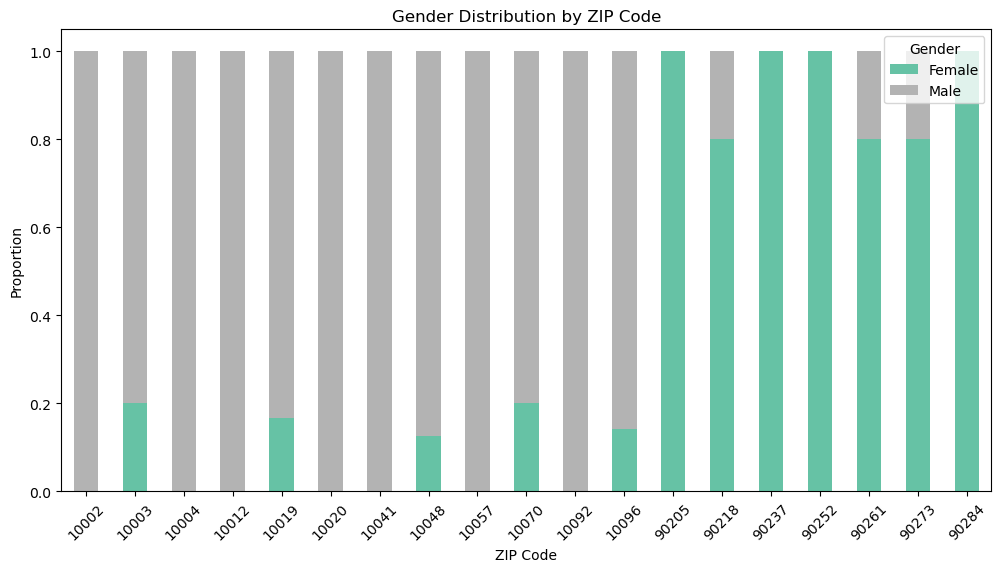

In [22]:
gender_zip = pd.crosstab(
    df_zip_filtered['applicant_info.zip_code'],
    df_zip_filtered['applicant_info.gender'],
    normalize='index'
)

gender_zip.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='Set2'
)

plt.title("Gender Distribution by ZIP Code")
plt.ylabel("Proportion")
plt.xlabel("ZIP Code")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.show()

In [13]:
zip_gender_table = pd.crosstab(
    df_zip_filtered['applicant_info.zip_code'],
    df_zip_filtered['applicant_info.gender']
)

chi2_zip_gender, p_zip_gender, dof, expected = chi2_contingency(zip_gender_table)

print("Chi-square statistic:", chi2_zip_gender)
print("p-value:", p_zip_gender)

Chi-square statistic: 77.7682011189474
p-value: 2.0997882846017237e-09


The chi-square test between ZIP code and gender produced a statistic of
**77.77** with a **p-value < 0.001**.

Because the p-value is far below the conventional 0.05 threshold, we
reject the null hypothesis that gender distribution is independent of
ZIP code. This indicates that gender composition differs significantly
across geographic locations in the dataset.

This result suggests that ZIP code may encode demographic patterns
related to gender. In principle, this could create the potential for
proxy discrimination if geographic variables were used in credit
decision models.

However, as shown in the previous section, ZIP code itself does not
have a statistically significant relationship with loan approval
outcomes. Therefore, despite the demographic clustering observed here,
ZIP code does not appear to function as a proxy for gender in the
approval decisions contained in this dataset.

#### 3.2.3 Age Distribution Across ZIP Codes

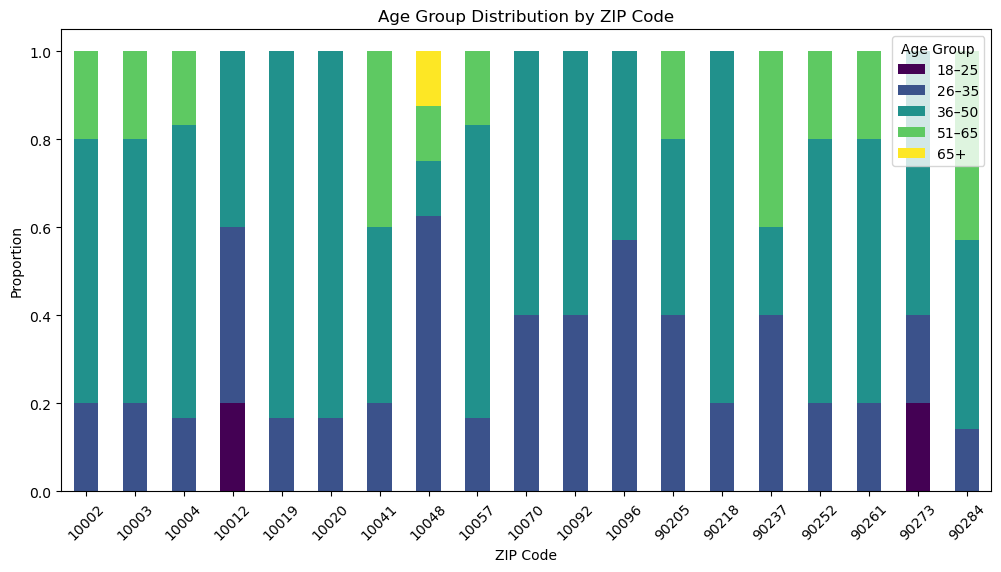

In [14]:
age_zip = pd.crosstab(
    df_zip_filtered['applicant_info.zip_code'],
    df_zip_filtered['age_group'],
    normalize='index'
)

age_zip.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='viridis'
)

plt.title("Age Group Distribution by ZIP Code")
plt.ylabel("Proportion")
plt.xlabel("ZIP Code")
plt.xticks(rotation=45)
plt.legend(title="Age Group")
plt.show()

In [15]:
zip_age_table = pd.crosstab(
    df_zip_filtered['applicant_info.zip_code'],
    df_zip_filtered['age_group']
)
chi2_zip_age, p_zip_age, dof, expected = chi2_contingency(zip_age_table)

print("Chi-square statistic:", chi2_zip_age)
print("p-value:", p_zip_age)

Chi-square statistic: 63.52881343142804
p-value: 0.75159975799866


The chi-square test between ZIP code and age group produced a statistic
of **63.53** with a **p-value of 0.75**.

Because this p-value is well above the 0.05 significance threshold, we
fail to reject the null hypothesis that age distribution is independent
of ZIP code.

This suggests that age groups are relatively evenly distributed across
geographic locations in the dataset. As a result, ZIP code does not
appear to encode meaningful age-related demographic patterns.

### 3.3 Financial Attributes as Potential Proxy Variables

Proxy discrimination may occur when non-protected attributes correlate
with protected characteristics and influence decision outcomes.

Financial variables such as income, credit history length, savings
balance, or debt-to-income ratio may reflect demographic differences,
particularly across age groups. If these financial attributes correlate
with protected characteristics, they may indirectly transmit demographic
patterns into credit decisions.

To examine this possibility, we compute correlations between key
financial attributes and demographic variables (age and gender).

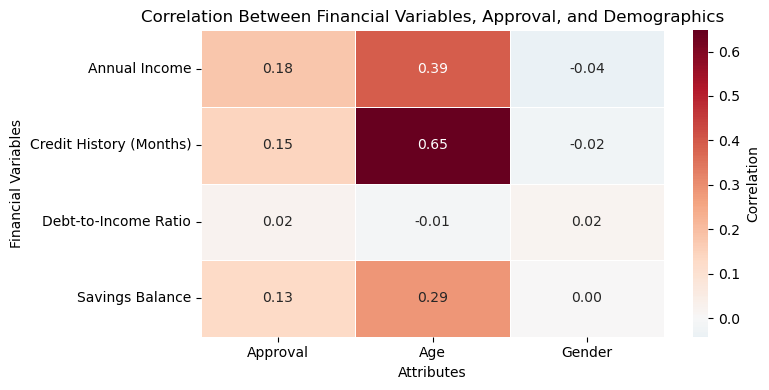

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Create working copy ---
df_corr = df_bias.copy()

# --- Encode demographic variables ---
df_corr["gender_binary"] = df_corr["applicant_info.gender"].map({
    "Male": 1,
    "Female": 0
})

# Use continuous age instead of age group
df_corr["age_numeric"] = df_corr["age"]

# --- Define financial variables ---
financial_vars = [
    "financials.annual_income",
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance"
]

# --- Build correlation matrix ---
proxy_corr = df_corr[
    financial_vars + [
        "decision.loan_approved",
        "age_numeric",
        "gender_binary"
    ]
].corr()

# Extract only financial variables vs attributes
proxy_matrix = proxy_corr.loc[
    financial_vars,
    [
        "decision.loan_approved",
        "age_numeric",
        "gender_binary"
    ]
]

# --- Improve column names for readability ---
proxy_matrix.columns = [
    "Approval",
    "Age",
    "Gender"
]

proxy_matrix.index = [
    "Annual Income",
    "Credit History (Months)",
    "Debt-to-Income Ratio",
    "Savings Balance"
]

# --- Plot heatmap ---
plt.figure(figsize=(8,4))

sns.heatmap(
    proxy_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    fmt=".2f",
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Between Financial Variables, Approval, and Demographics")
plt.xlabel("Attributes")
plt.ylabel("Financial Variables")

plt.tight_layout()
plt.show()

The correlation matrix highlights the relationships between financial
variables, loan approval outcomes, and demographic attributes.

Several financial variables show weak but positive relationships with
loan approval, particularly annual income (0.18), credit history length
(0.15), and savings balance (0.13). This suggests that applicants with
stronger financial profiles are slightly more likely to receive loan
approval.

At the same time, some financial variables exhibit moderate correlations
with age. Credit history length shows the strongest relationship with
age (0.65), while income (0.39) and savings balance (0.29) also increase
with age. These patterns are consistent with expected financial
accumulation over the life cycle.

In contrast, correlations between financial attributes and gender are
close to zero across all variables, indicating that financial
characteristics do not differ substantially between male and female
applicants in this dataset.

Overall, these results suggest that financial attributes may indirectly
reflect age-related financial patterns. However, the relationships
observed are consistent with legitimate creditworthiness indicators
rather than explicit demographic discrimination.

## 4. Interaction Effects: Age and Gender

Interaction effects occur when the combined influence of two attributes
produces patterns that are not visible when analyzing each attribute
individually.

In the context of fairness analysis, this is important because certain
subgroups may experience different outcomes even when overall demographic
patterns appear balanced. For example, approval rates may differ for
older women compared to younger men, even if gender or age alone does
not strongly predict approval.

To investigate this possibility, we examine loan approval rates across
combined age and gender groups.

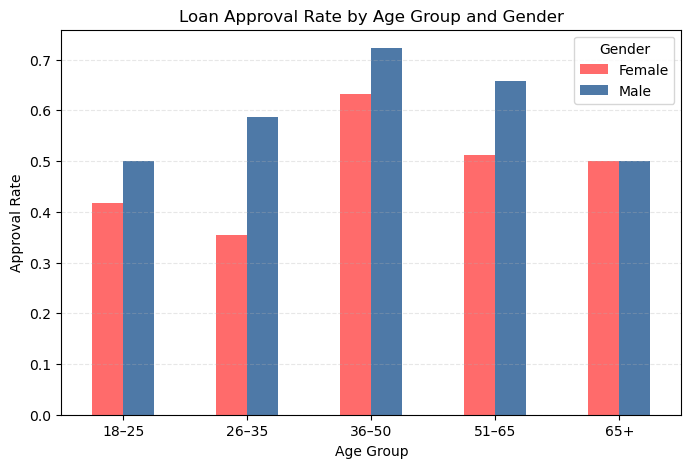

In [17]:
interaction_table = pd.crosstab(
    [df_bias["age_group"], df_bias["applicant_info.gender"]],
    df_bias["decision.loan_approved"],
    normalize="index"
)

interaction_approval = interaction_table[True].unstack()

interaction_approval.plot(
    kind="bar",
    figsize=(8,5),
    color=["#FF6B6B", "#4E79A7"]
)

plt.title("Loan Approval Rate by Age Group and Gender")
plt.ylabel("Approval Rate")
plt.xlabel("Age Group")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()


The visualization shows loan approval rates for male and female
applicants within each age group.

Across most age categories, male applicants exhibit higher approval
rates than female applicants. The difference is particularly visible in
the 26–35 and 51–65 age groups, where male approval rates exceed female
approval rates by a noticeable margin. In contrast, approval rates
appear more similar for applicants aged 65 and above.

In [18]:
interaction_counts = pd.crosstab(
    [df_bias["age_group"], df_bias["applicant_info.gender"]],
    df_bias["decision.loan_approved"]
)

from scipy.stats import chi2_contingency

chi2_interaction, p_interaction, dof, expected = chi2_contingency(interaction_counts)

print("Chi-square statistic:", chi2_interaction)
print("p-value:", p_interaction)

Chi-square statistic: 32.02705987701472
p-value: 0.00019699520358552463


The chi-square test for the interaction between age group and gender
produced a statistic of **32.03** with a **p-value of 0.0002**. Because
this value is well below the 0.05 significance threshold, we reject the
null hypothesis that loan approval outcomes are independent of the
combined age–gender categories.

This indicates that approval decisions vary significantly across
age–gender subgroups. In other words, the effect of gender on approval
outcomes differs depending on the applicant’s age group.

#### 4.1 Disparate Impact by Age Group

To further examine the interaction between age and gender, disparate
impact ratios were calculated separately for each age group.

This analysis evaluates whether the gender approval gap differs across
age categories using the four-fifths rule (DI < 0.8).

In [19]:
di_by_age = []

age_groups = df_bias["age_group"].unique()

for age in age_groups:
    
    subset = df_bias[df_bias["age_group"] == age]
    
    approval_rates = subset.groupby("applicant_info.gender")["decision.loan_approved"].mean()
    
    if "Male" in approval_rates and "Female" in approval_rates:
        di = approval_rates["Female"] / approval_rates["Male"]
    else:
        di = None
    
    di_by_age.append({
        "Age Group": age,
        "Male Approval Rate": approval_rates.get("Male", None),
        "Female Approval Rate": approval_rates.get("Female", None),
        "DI Ratio (F/M)": di
    })

# Create dataframe
di_age_df = pd.DataFrame(di_by_age)

# Add fairness threshold column (Four-Fifths Rule)
di_age_df["Below 0.8 Threshold"] = di_age_df["DI Ratio (F/M)"] < 0.8

# Optional: sort age groups for cleaner display
age_order = ["18–25", "26–35", "36–50", "51–65", "65+"]
di_age_df["Age Group"] = pd.Categorical(di_age_df["Age Group"], categories=age_order, ordered=True)
di_age_df = di_age_df.sort_values("Age Group")

di_age_df

,Age Group,Male Approval Rate,Female Approval Rate,DI Ratio (F/M),Below 0.8 Threshold
0,18–25,0.500000,0.416667,0.833333,False
1,26–35,0.586667,0.353659,0.602827,True
2,36–50,0.722689,0.632075,0.874616,False
3,51–65,0.657895,0.511111,0.776889,True
4,65+,0.500000,0.500000,1.000000,False


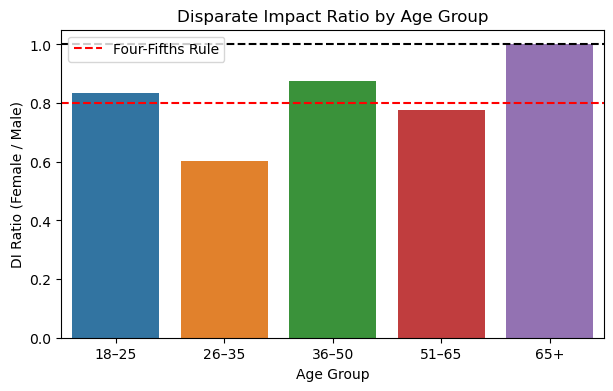

In [20]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=di_age_df,
    x="Age Group",
    y="DI Ratio (F/M)"
)

plt.axhline(0.8, color="red", linestyle="--", label="Four-Fifths Rule")
plt.axhline(1.0, color="black", linestyle="--")

plt.title("Disparate Impact Ratio by Age Group")
plt.ylabel("DI Ratio (Female / Male)")
plt.legend()

plt.show()

The results show that gender disparities are not uniform across age
categories. In particular, the **26–35 age group exhibits a DI ratio of
0.60**, indicating a substantial gap in approval rates between female
and male applicants. A smaller disparity is also observed for the
**51–65 age group**, where the DI ratio falls slightly below the
four-fifths threshold (0.78).

In contrast, other age groups show more balanced outcomes, with DI
ratios above the fairness threshold or equal approval rates.

These findings suggest that gender-related differences in approval
outcomes may be concentrated in specific demographic subgroups rather
than occurring uniformly across the population.

### Conclusion

While approval rates vary across age–gender combinations, the
disparate impact analysis shows that gender disparities are not
uniform across all age groups. In particular, the 26–35 and 51–65
categories exhibit DI ratios below the four-fifths threshold,
indicating potential gender-based disparities in these subgroups.

At the same time, earlier proxy analysis showed that several financial
attributes—such as income, credit history length, and savings
balance—are moderately correlated with age. These financial factors
may partly contribute to the observed differences in approval outcomes.

From a governance perspective, these findings highlight the importance
of monitoring **subgroup-level fairness metrics**, since disparities may
emerge only within specific demographic segments even when aggregate
fairness measures appear acceptable.

## 6. Bias Analysis Summary and Governance Implications

This analysis investigated potential bias patterns in historical credit
decisions by examining gender disparities, age-related trends, proxy
variables, and interaction effects between demographic attributes.

The results indicate several patterns that merit attention. First,
approval rates differ between male and female applicants, suggesting
that gender-related disparities may exist in the historical decisions.
Second, approval outcomes vary across age groups. However, financial
variables such as income, savings balance, and credit history length
are moderately correlated with age, indicating that some differences
may arise from legitimate financial characteristics that accumulate
over time.

The proxy analysis found that ZIP codes are associated with gender
distribution but are not significantly related to approval outcomes.
This suggests that geographic information is unlikely to function as a
direct proxy for discrimination in this dataset. Financial variables,
however, show moderate correlations with age, meaning that demographic
patterns could still be indirectly reflected through financial
attributes used in credit evaluation.

Finally, the interaction analysis revealed statistically significant
differences across combined age–gender groups. This highlights the
importance of monitoring subgroup outcomes, as fairness issues may
emerge only when multiple demographic attributes are considered
together.

From a governance perspective, these findings underline the need for
regular fairness audits of credit decision systems. Monitoring metrics
such as disparate impact and subgroup approval rates can help detect
potential disparities early. At the same time, the presence of sensitive
personal data in the dataset requires appropriate privacy protections,
such as pseudonymization and access controls, as demonstrated in the
privacy analysis notebook.

Together, these governance practices help ensure that automated credit
decision systems remain transparent, fair, and compliant while
protecting sensitive personal information.